# Four-language benchmark: execution, libraries, memory and GPU work

This notebook asks where C++, Python, R and JavaScript (Node.js) spend time across **18 CPU, RAM and GPU tests**.
It connects measured throughput to the implementation, installed libraries and recorded machine configuration.
The results characterize these workloads and environments; a single score cannot predict every application's performance.

The implementations follow [common/SPEC.md](common/SPEC.md), with deterministic input formulas and explicit
timing boundaries. C++, Python and R use the same OpenCL sources; JavaScript uses a WebGPU translation.
Some full-mode input sizes differ by language. Verification uses identical small inputs and compares check values
under [test-specific tolerances](common/verify.py), rather than requiring every floating-point result to be bit-identical.

**To read the committed analysis**, start with section 3 for scores, sections 4–10 for the underlying measurements,
and sections 11–13 for findings, machine comparisons and conclusions. To refresh it, run the benchmark with
`./run_all.sh` (Linux/macOS) or `run_all.cmd` (Windows), then run all notebook cells from the repository root.
The settings below select the detailed machine; by default it is the one with the newest recorded run.

- **Rate** is work per second: higher is better. Units differ between tests, so raw rates cannot be averaged across tasks.
- **Relative throughput** divides one rate by a reference rate: 1× is equal; 0.1× is one tenth as fast.
- **Category scores** are geometric means of test ratios. **Overall** is the geometric mean of available categories.
- **Scope matters:** a best-configuration throughput score is not total suite runtime, energy efficiency or application speedup.

In [1]:
# ---- Settings (edit these) -------------------------------------------------------------
import os
from pathlib import Path

RESULTS = Path(os.environ.get("BENCH_RESULTS", "results"))  # one sub-folder per machine; relative to this notebook
MACHINE = os.environ.get("BENCH_VIEW_MACHINE") or None  # machine to analyse in detail (its folder name);
                                                        # None = the machine with the newest run
MODE = os.environ.get("BENCH_MODE", "full")  # "full", "quick" or "verify"; falls back to the newest mode found
BATCH = None      # e.g. "20261001-140000" to analyse one run_all.sh invocation only;
                  # None = newest run of each language (lets you run languages one at a time)

# Theoretical peaks are worked out per machine from results/<machine>/system_<batch>.csv (CPU flags,
# clock - measured by Cpp/hw_probe where the OS does not report it -, cores, RAM type/speed/modules, GPU compute
# units and memory bus), with the optional, hand-written results/<machine>/hardware.csv on top.
# If a guess is wrong, correct it here, e.g.
#   PEAK_OVERRIDES = {"my-desktop": {"ram_channels": 4, "cpu_fp64_flop_per_cycle": 32, "gpu_lanes_per_cu": 128}}
PEAK_OVERRIDES = {}

In [2]:
import glob, math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

# Chart style: light surface, hairline solid grid, recessive axes, thin marks.
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
LANGS = ["C++", "Python", "R", "JavaScript"]
COLORS = {"C++": "#2a78d6", "Python": "#eb6834", "R": "#1baf7a", "JavaScript": "#eda100"}  # fixed per language
# Four hues pass the colour-vision checks for bars and lines (neighbours only), not for scatter plots,
# so the one scatter chart is split into one panel per language, and lines carry name labels.
PHASE_NAMES = {"cpp": "C++", "python": "Python", "r": "R", "js": "JavaScript"}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Cantarell", "Noto Sans", "DejaVu Sans"], "font.size": 9.5,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "legend.labelcolor": INK2,
    "lines.linewidth": 2, "lines.markersize": 6, "axes.unicode_minus": False,
})

# Display unit for each work unit, so every chart of one unit shares an axis.
DISPLAY = {"FLOP": (1e9, "GFLOP/s"), "B": (1e9, "GB/s"), "access": (1e6, "M accesses/s"),
           "px": (1e6, "M px/s"), "iter": (1e6, "M iter/s"), "call": (1e6, "M calls/s"),
           "elem": (1e6, "M elem/s"), "item": (1e6, "M items/s"), "op": (1e6, "M ops/s")}

def fmt(v, digits=3):
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return "-"
    return f"{v:.{digits}g}" if abs(v) < 10 ** digits else f"{v:,.0f}"

def legend_handles(langs):
    return [plt.Line2D([], [], color=COLORS[l], lw=6, label=l) for l in langs]

def hbar_groups(ax, groups, langs, value_of, label_of=None, log=False):
    # Horizontal grouped bars: one group per entry of `groups`, one thin bar per language.
    h = 0.62 / max(len(langs), 1)
    for gi, g in enumerate(groups):
        for li, lang in enumerate(langs):
            v = value_of(g, lang)
            if v is None or not np.isfinite(v) or v <= 0:
                continue
            y = gi + (li - (len(langs) - 1) / 2) * h
            ax.barh(y, v, height=h, color=COLORS[lang], edgecolor=SURFACE, linewidth=1.5)
            ax.text(v, y, "  " + (label_of(g, lang, v) if label_of else fmt(v)),
                    va="center", ha="left", fontsize=8, color=INK2)
    ax.set_yticks(range(len(groups)), groups)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    if log:
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.margins(x=0.25)

def end_label(ax, x, y, text, color=INK2):
    # Label at the end of a line; finish_layout() moves apart labels that would overlap.
    ax.annotate(text, xy=(x, y), xytext=(5, 0), textcoords="offset points", ha="left", va="center",
                fontsize=8, color=color, gid="end-label", annotation_clip=False,
                arrowprops=dict(arrowstyle="-", color=AXIS, lw=0.8, relpos=(0, 0.5), shrinkA=1, shrinkB=4))

def spread_end_labels(ax):
    # Labels closer than one text line are spread evenly around their mean height and joined to
    # their line end by a thin leader. Works in pixels, so it must run after the layout is final.
    labels = [t for t in ax.texts if t.get_gid() == "end-label"]
    if not labels:
        return
    px = ax.figure.dpi / 72                       # pixels per point
    gap = 8 * 1.4 * px                            # one line of 8 pt text
    anchor = {t: ax.transData.transform(t.xy)[1] for t in labels}
    clusters = [[t] for t in sorted(labels, key=anchor.get)]

    def heights(c):
        mid = np.mean([anchor[t] for t in c])
        return [mid + (k - (len(c) - 1) / 2) * gap for k in range(len(c))]

    k = 0
    while k < len(clusters) - 1:
        if heights(clusters[k])[-1] + gap > heights(clusters[k + 1])[0] + 0.5:
            clusters[k:k + 2] = [clusters[k] + clusters[k + 1]]
            k = max(k - 1, 0)                     # the merged cluster grew; recheck the one below
        else:
            k += 1
    for c in clusters:
        for t, y in zip(c, heights(c)):
            dy = (y - anchor[t]) / px
            moved = abs(dy) > 1
            t.xyann = (12 if moved else 5, dy)
            t.arrow_patch.set_visible(moved)

def finish_layout(fig, langs=()):
    # One legend for the whole figure, in its own row above every panel title, right-aligned, so it
    # never covers a title or data; then lay out the panels and spread end-of-line labels.
    rect = (0, 0, 1, 1)
    if len(langs):
        leg = fig.legend(handles=legend_handles(langs), loc="upper right", bbox_to_anchor=(1, 1),
                         ncols=len(langs), borderaxespad=0.2, handlelength=1.2)
        h = leg.get_window_extent(fig.canvas.get_renderer()).height / fig.bbox.height
        rect = (0, 0, 1, 1 - h)
    fig.tight_layout(rect=rect)
    for ax in fig.axes:
        spread_end_labels(ax)

def peak_line(ax, x, text):
    # Reference line for a theoretical peak, labelled at the bottom.
    if x is None or not np.isfinite(x):
        return
    ax.axvline(x, color=AXIS, lw=1)
    ax.text(x, 0.02, f"{text} ", transform=ax.get_xaxis_transform(), color=MUTED, fontsize=8,
            ha="right", va="bottom")

## 1. Select the observations

Read every machine under `results/`. Sections 2–11 use the newest run of each language in the selected mode,
or the selected batch if `BATCH` is set. Languages can therefore come from different invocations of the runner.
Section 12 selects the newest run per language and machine independently of `BATCH`.
Check the run IDs and test counts below before interpreting a score. A full-mode run can still contain skipped
or filtered tests; absent results are not zero throughput.

In [3]:
def read_kv(path):
    m = pd.read_csv(path, dtype=str, keep_default_na=False)
    return dict(zip(m["key"], m["value"]))

def read_results(root):
    # Every <run_id>.csv under root (any depth) with its _meta.csv; machine = meta value or folder name.
    frames, metas = [], {}
    for path in sorted(Path(root).rglob("*.csv")):
        if path.name.startswith(("sensors_", "system_")) or path.name.endswith("_meta.csv"):
            continue
        d = pd.read_csv(path, dtype={"batch": str})
        if d.empty or "run_id" not in d:
            continue
        meta_path = path.with_name(path.stem + "_meta.csv")
        m = read_kv(meta_path) if meta_path.exists() else {}
        rel = path.relative_to(root)
        d["machine"] = m.get("machine") or (rel.parts[0] if len(rel.parts) > 1 else "unknown")
        d["run_key"] = d["machine"] + "/" + d["run_id"]
        d["folder"] = str(path.parent)
        frames.append(d)
        metas[d.run_key.iloc[0]] = m
    if not frames:
        raise SystemExit(f"No results in {Path(root).resolve()} - run ./run_all.sh first.")
    return pd.concat(frames, ignore_index=True), metas

def read_systems(root):
    # {machine: [system snapshot dicts, oldest first]} from system_<batch>.csv written by run_all.sh
    systems = {}
    for path in sorted(Path(root).rglob("system_*.csv")):
        d = read_kv(path)
        systems.setdefault(d.get("machine") or path.parent.name, []).append(d)
    return systems

rows, metas = read_results(RESULTS)
systems = read_systems(RESULTS)
runs = rows.groupby("run_key").agg(machine=("machine", "first"), run_id=("run_id", "first"),
                                   language=("language", "first"), mode=("mode", "first"),
                                   batch=("batch", "first"), tests=("test", "nunique")).reset_index()
runs["started"] = runs.run_id.str.split("_").str[-1]
machine = MACHINE or runs.sort_values("started").machine.iloc[-1]
if machine not in set(runs.machine):
    raise SystemExit(f"No results for machine '{machine}'. Available: {sorted(set(runs.machine))}")
here = runs[runs.machine == machine]
if BATCH:
    here = here[here.batch == str(BATCH)]
mode = MODE if (here["mode"] == MODE).any() else here.sort_values("started")["mode"].iloc[-1]
if mode != MODE:
    print(f"No '{MODE}' runs found for {machine} - using the newest mode available: '{mode}'.")
chosen = here[here["mode"] == mode].sort_values("started").groupby("language").tail(1)
data = rows[rows.run_key.isin(chosen.run_key)].copy()
langs = [l for l in LANGS if l in set(data.language)]
REF = "C++" if "C++" in langs else langs[0]          # reference language for "x C++" ratios

tests_spec = pd.read_csv(RESULTS.parent / "common" / "tests.csv") if (RESULTS.parent / "common" / "tests.csv").exists() \
    else pd.read_csv("common/tests.csv")
TEST_ORDER = list(tests_spec.test)
CATEGORIES = ["cpu_single", "cpu_multi", "ram", "gpu"]
CAT_TITLES = {"cpu_single": "CPU, single core", "cpu_multi": "CPU, all cores", "ram": "RAM", "gpu": "GPU"}

print(f"Machines with results: {', '.join(sorted(set(runs.machine)))}")
print(f"Analysing: {machine}  (mode: {mode})")
if mode == "verify":
    print("Note: verify-mode sizes are tiny; rates are not meaningful (use it to check correctness only).")
display(chosen[["language", "run_id", "batch", "mode", "tests"]].set_index("language").loc[langs])

Machines with results: alienware-m16-r1, apple-inc-macbook-pro-14-inch-m5-pro, dell-inc-inspiron-14-7425-2-in-1
Analysing: apple-inc-macbook-pro-14-inch-m5-pro  (mode: full)


,run_id,batch,mode,tests
language,,,,
C++,cpp_20261001-215336,20261001-215334,full,18
Python,python_20261001-215358,20261001-215334,full,18
R,r_20261001-215428,20261001-215334,full,18
JavaScript,js_20261001-215708,20261001-215334,full,18


## 2. Hardware, software and peak assumptions

The system snapshots and per-language metadata identify the environment behind each result. BLAS, compiler,
GPU API and runtime version are part of that environment. In particular, a single-threaded reference BLAS and
a threaded optimized BLAS measure different software configurations even when both are called from R.

Peak rates below are estimates based on clocks, assumed SIMD widths, core types and memory buses. The model
uses the highest recorded clocks, which need not occur simultaneously under sustained load. `hardware.csv`
provides persistent corrections; `PEAK_OVERRIDES` changes this notebook's estimates. Percentages against these
models are context for the measured rates, not direct measurements of hardware utilization.

In [4]:
def system_of(m, batches=()):
    # The machine's system snapshot (the one from one of `batches` if present, else its newest), with the
    # values of the optional, hand-written results/<machine>/hardware.csv applied on top.
    snaps = systems.get(m, [])
    snap = dict(next((d for d in reversed(snaps) if d.get("batch") in batches), snaps[-1] if snaps else {}))
    # measured clocks depend on the load at that moment: the highest any snapshot of the machine recorded
    for k in ("cpu_max_mhz", "cpu_e_max_mhz", "gpu_clock_max_logged_mhz"):
        vals = [num(d.get(k)) for d in snaps if np.isfinite(num(d.get(k)))]
        if vals:
            snap[k] = f"{max(vals):.0f}"
    hw = RESULTS / m / "hardware.csv"
    return {**snap, **{k: v for k, v in read_kv(hw).items() if v}} if hw.exists() else snap

def num(x, default=np.nan):
    try:
        return float(x)
    except (TypeError, ValueError):
        return default

def machine_peaks(m, sysinfo, meta_list):
    # Theoretical peaks for machine m, from its system snapshot and run metadata (guesses explained).
    o = PEAK_OVERRIDES.get(m, {})
    first = lambda key: next((x[key] for x in meta_list if x.get(key) not in (None, "")), "")
    cpu = sysinfo.get("cpu") or first("cpu")
    apple = cpu.lower().startswith("apple m")
    flags = set(sysinfo.get("cpu_flags", "").split())
    phys = num(sysinfo.get("physical_cores"), num(first("physical_cores"), 1))
    p_cores, e_cores = num(sysinfo.get("performance_cores")), num(sysinfo.get("efficiency_cores"), 0)
    ghz, e_ghz = num(sysinfo.get("cpu_max_mhz")) / 1000, num(sysinfo.get("cpu_e_max_mhz")) / 1000
    if apple:
        fpc, why = 16, "Apple Silicon: four 128-bit FMA pipes per performance core"
    elif "avx512f" in flags and "intel" in cpu.lower():
        fpc, why = 32, "AVX-512 with two FMA units"
    elif {"avx2", "fma"} <= flags:
        fpc, why = 16, "AVX2: two 256-bit FMA units"
    elif "avx" in flags or "asimd" in flags:
        fpc, why = 8, "128/256-bit SIMD"
    else:
        fpc, why = 4, "no wide SIMD flags found"
    fpc = o.get("cpu_fp64_flop_per_cycle", fpc)
    ram_type = sysinfo.get("ram_type", "")
    mts = o.get("ram_mts", num(sysinfo.get("ram_speed_mts")))
    modules = int(num(sysinfo.get("ram_modules"), 0))
    bus = num(sysinfo.get("ram_bus_bits"))      # from hardware.csv where the OS reports no modules (Macs)
    channels = o.get("ram_channels", int(bus // 64) if np.isfinite(bus) else
                     2 if ram_type.startswith("LPDDR") or modules >= 2 else max(modules, 1))
    gpu = first("gpu_device")
    lanes = o.get("gpu_lanes_per_cu", 128 if re.search(r"nvidia|geforce|rtx|quadro|apple", gpu, re.I)
                  else 8 if re.search(r"intel|iris|uhd|arc", gpu, re.I) else 64)
    cus = num(first("gpu_compute_units"))
    # the GPU may boost above the clock its driver reports: the highest clock the sensor log saw counts if higher
    mhz = max((v for v in (num(first("gpu_max_clock_mhz")), num(sysinfo.get("gpu_clock_max_logged_mhz")),
                           num(sysinfo.get("gpu_max_clock_mhz"))) if np.isfinite(v)), default=np.nan)
    hybrid = np.isfinite(p_cores) and e_cores > 0 and np.isfinite(e_ghz)
    discrete = bool(re.search(r"nvidia|geforce|rtx|gtx|quadro|radeon rx|radeon pro|arc a\d", gpu, re.I))
    ram_gbs = mts * 1e6 * 8 * channels / 1e9
    peaks = {"cpu_fp64_gflops": (p_cores * fpc * ghz + e_cores * fpc / 2 * e_ghz) if hybrid else phys * fpc * ghz,
             "ram_gbs": ram_gbs,
             "gpu_fp32_gflops": cus * lanes * 2 * mhz / 1e3,
             # an integrated GPU uses system RAM; a discrete GPU's own memory comes from hardware.csv
             "gpu_mem_gbs": o.get("gpu_memory_gbs", num(sysinfo.get("gpu_memory_gbs"))) if discrete else ram_gbs}
    pn, en = sysinfo.get("performance_core_name") or "P", sysinfo.get("efficiency_core_name") or "E"
    cpu_why = (f"{p_cores:.0f} {pn}-cores x {fpc} FLOP/cycle x {ghz:.2f} GHz + {e_cores:.0f} {en}-cores x {fpc // 2} FLOP/cycle x {e_ghz:.2f} GHz ({why})"
               if hybrid else f"{phys:.0f} cores x {fpc} FLOP/cycle ({why}) x {ghz:.2f} GHz")
    explain = {
        "CPU FP64 peak (GFLOP/s)": (f"{peaks['cpu_fp64_gflops']:.0f} = {cpu_why}" if np.isfinite(peaks["cpu_fp64_gflops"])
                                    else "unknown (no maximum clock: build Cpp/hw_probe, or add cpu_max_mhz to hardware.csv)"),
        "RAM bandwidth peak (GB/s)": (f"{peaks['ram_gbs']:.1f} = {mts:.0f} MT/s x 8 B x {channels} channels ({ram_type or '?'}, "
                                      + (f"{bus:.0f}-bit bus)" if np.isfinite(bus) else f"{modules} modules)")
                                      if np.isfinite(mts) else "unknown (RAM speed not in the system snapshot (macOS does not report it); "
                                      "add ram_speed_mts and ram_bus_bits to hardware.csv, or set PEAK_OVERRIDES)"),
        "GPU FP32 peak (GFLOP/s)": (f"{peaks['gpu_fp32_gflops']:.0f} = {cus:.0f} {'GPU cores' if 'apple' in gpu.lower() else 'compute units'} x {lanes} lanes x 2 x {mhz:.0f} MHz"
                                    if np.isfinite(peaks["gpu_fp32_gflops"]) else "unknown (no OpenCL GPU results)"),
        "GPU memory peak (GB/s)": (("unknown (discrete GPU: no gpu_memory_gbs in the system snapshot; add it to hardware.csv)" if not np.isfinite(peaks["gpu_mem_gbs"])
                                    else f"{peaks['gpu_mem_gbs']:.0f} (discrete GPU: memory bus from the CUDA driver, in the system snapshot)") if discrete
                                   else f"{peaks['gpu_mem_gbs']:.1f} (integrated GPU: the RAM peak)"),
    }
    return peaks, explain

run_meta = {l: metas.get(chosen.set_index("language").run_key[l], {}) for l in langs}
SYSTEM = system_of(machine, set(chosen.batch))
if SYSTEM:
    keys = ["machine", "vendor", "product", "cpu", "cpu_max_mhz", "cpu_e_max_mhz", "physical_cores", "performance_cores", "efficiency_cores",
            "performance_core_name", "efficiency_core_name",
            "logical_cpus", "cpu_flags",
            "l3_cache", "ram_gib", "ram_type", "ram_speed_mts", "ram_modules", "ram_bus_bits", "gpus", "gpu_cores", "gpu_max_clock_mhz",
            "opencl_devices", "os", "kernel",
            "power", "platform_profile", "governor", "transparent_hugepages", "suite_commit", "suite_tests_sha"]
    display(pd.Series({k: SYSTEM.get(k, "") or "-" for k in keys}, name=machine).to_frame())
else:
    print("No system snapshot for this machine (runs were not started with run_all.sh); peaks use run metadata only.")

KEYS = ["language_version", "build", "blas", "numpy_version", "gpu_device", "gpu_driver", "gpu_compute_units",
        "gpu_max_clock_mhz", "cpu_temp_start_c", "cpu_temp_end_c", "elapsed_s", "skipped", "failed"]
meta = pd.DataFrame(run_meta).reindex(KEYS).replace("", "-").fillna("-")
with pd.option_context("display.max_colwidth", 70):
    display(meta)

PEAK, peak_explain = machine_peaks(machine, SYSTEM, list(run_meta.values()))
PHYS = int(num(SYSTEM.get("physical_cores"), num(next((x.get("physical_cores") for x in run_meta.values()), 1), 1)))
LOGICAL = int(num(SYSTEM.get("logical_cpus"), num(next((x.get("logical_cpus") for x in run_meta.values()), 1), 1)))
display(pd.Series(peak_explain, name="theoretical peak (correct with PEAK_OVERRIDES)").to_frame())

,apple-inc-macbook-pro-14-inch-m5-pro
machine,apple-inc-macbook-pro-14-inch-m5-pro
vendor,Apple Inc.
product,"MacBook Pro (14-inch, M5 Pro)"
cpu,Apple M5 Pro
cpu_max_mhz,4608
cpu_e_max_mhz,4345
physical_cores,15
performance_cores,5
efficiency_cores,10
performance_core_name,Super


,C++,Python,R,JavaScript
language_version,clang++ Apple LLVM 21.0.0 (clang-2100.1.1.101),CPython 3.14.7,R 4.5.3,Node.js v25.9.0 (V8 14.1.146.11-node.25)
build,clang++ -O3 -march=native -ffp-contract=off -std=c++20 -pthread,~/Documents/GitHub/benchmark/.venv/bin/python,/Library/Frameworks/R.framework/Resources,/opt/homebrew/Cellar/node/25.9.0_2/bin/node --expose-gc
blas,OpenBLAS 0.3.34 DYNAMIC_ARCH NO_AFFINITY USE_OPENMP vortexm4 MAX_T...,accelerate,/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/l...,OpenBLAS 0.3.34 DYNAMIC_ARCH NO_AFFINITY USE_OPENMP vortexm4 MAX_T...
numpy_version,-,2.5.3,-,-
gpu_device,Apple M5 Pro,Apple M5 Pro,Apple M5 Pro,apple-m5-pro
gpu_driver,1.2 1.0,1.2 1.0,1.2 1.0,Metal driver on macOS Version 26.5.2 (Build 25F84)
gpu_compute_units,16,16,16,-
gpu_max_clock_mhz,1000,1000,1000,-
cpu_temp_start_c,58.9,59.5,60.8,59.2
cpu_temp_end_c,58.6,59.4,59.6,61.7


,theoretical peak (correct with PEAK_OVERRIDES)
CPU FP64 peak (GFLOP/s),716 = 5 Super-cores x 16 FLOP/cycle x 4.61 GHz...
RAM bandwidth peak (GB/s),"307.2 = 9600 MT/s x 8 B x 4 channels (LPDDR5X,..."
GPU FP32 peak (GFLOP/s),6636 = 16 GPU cores x 128 lanes x 2 x 1620 MHz
GPU memory peak (GB/s),307.2 (integrated GPU: the RAM peak)


## 3. Relative throughput and score construction

First take the median rate within each test/size/worker configuration of the selected run. Then select the
highest median for each language and test. This uses the **best measured configuration**, which may differ
across languages: C++'s triad can use multiple threads, while the other implementations use one.
Allocation may select different sizes because larger sizes are skipped when available memory is insufficient.

For test *t* and language *l*, the ratio is `rate(l, t) / rate(reference, t)`. The category score is
`exp(mean(log(test ratios)))`; Overall applies the same formula to category scores. With all four categories,
each contributes 25%, regardless of test count or elapsed time. Missing ratios are omitted, so incomplete
coverage can change the meaning of a score. C++ is the reference when present; otherwise the first available language is used.

The log scale keeps 0.01× and 1× readable together. Normalizing by work does not remove input-size effects:
cache behavior, algorithmic cost per item and fixed overhead can all change with size. Small score differences
should be assessed against repeated runs, rather than interpreted as established performance advantages.

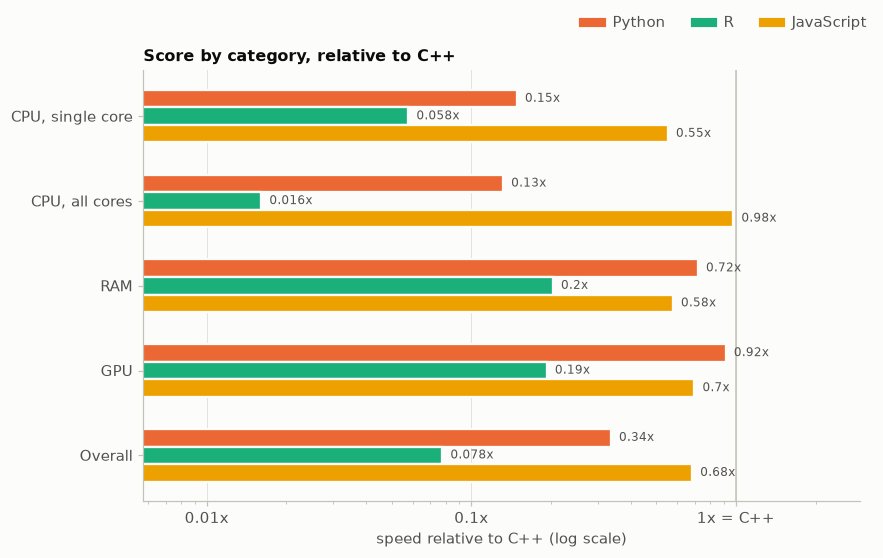

language,C++,Python,R,JavaScript
"CPU, single core",1x,0.149x,0.0579x,0.554x
"CPU, all cores",1x,0.132x,0.0161x,0.979x
RAM,1x,0.719x,0.204x,0.579x
GPU,1x,0.917x,0.193x,0.698x
Overall,1x,0.337x,0.0778x,0.684x


,tests contributing a ratio
language,
C++,18
Python,18
R,18
JavaScript,18


In [5]:
med = (data.groupby(["language", "category", "test", "style", "unit", "threads", "size"], as_index=False)
           .agg(seconds=("seconds", "median"), rate=("rate", "median"), reps=("rate", "size"),
                cv=("rate", lambda r: r.std(ddof=0) / r.mean() if len(r) > 1 else np.nan)))
best = med.loc[med.groupby(["language", "test"]).rate.idxmax()]
rate_by = best.pivot(index="test", columns="language", values="rate")
rate_by = rate_by.reindex([t for t in TEST_ORDER if t in rate_by.index])[langs]
ratio = rate_by.div(rate_by[REF], axis=0)
test_cat = tests_spec.set_index("test").category

def gmean(s):
    s = s.dropna()
    return float(np.exp(np.log(s).mean())) if len(s) else np.nan

cat_score = pd.DataFrame({c: ratio[test_cat.reindex(ratio.index) == c].apply(gmean) for c in CATEGORIES}).T
cat_score = cat_score.dropna(how="all")
overall = cat_score.apply(gmean)
scores = pd.concat([cat_score, overall.to_frame("overall").T])
labels = [CAT_TITLES.get(c, "Overall") for c in scores.index]

others = [l for l in langs if l != REF]   # REF is 1x by definition: drawn as the reference line
fig, ax = plt.subplots(figsize=(8, 0.5 * len(scores) * max(len(others), 2) / 2 + 1.3))
hbar_groups(ax, list(scores.index), others, lambda g, l: scores.loc[g, l],
            label_of=lambda g, l, v: f"{v:.2g}x", log=True)
ax.set_yticklabels(labels)
ax.set_xlim(right=max(2, np.nanmax(scores[others].values) * 3) if others else 2)
ax.axvline(1, color=AXIS, lw=1)
ax.set_xlabel(f"speed relative to {REF} (log scale)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"1x = {REF}" if v == 1 else f"{v:g}x"))
ax.set_title(f"Score by category, relative to {REF}")
finish_layout(fig, others); plt.show()

display(scores.rename(index=dict(zip(scores.index, labels))).map(lambda v: f"{v:.3g}x" if np.isfinite(v) else "-"))

# Reuse the page's scope calculation so exclusions and category weights stay consistent.
from docs.build_page import scope_summary, blas_kind
flagged_gpu = (SYSTEM.get("os", "").lower().startswith("macos")
               and "JavaScript" in rate_by and "gpu_fp32_peak" in rate_by.index
               and np.isfinite(PEAK["gpu_fp32_gflops"])
               and rate_by.loc["gpu_fp32_peak", "JavaScript"] / 1e9 > 1.05 * PEAK["gpu_fp32_gflops"])
scope = scope_summary(ratio, test_cat, ["gpu_fp32_peak"] if flagged_gpu else [])
display(ratio.notna().sum().rename("tests contributing a ratio").to_frame())

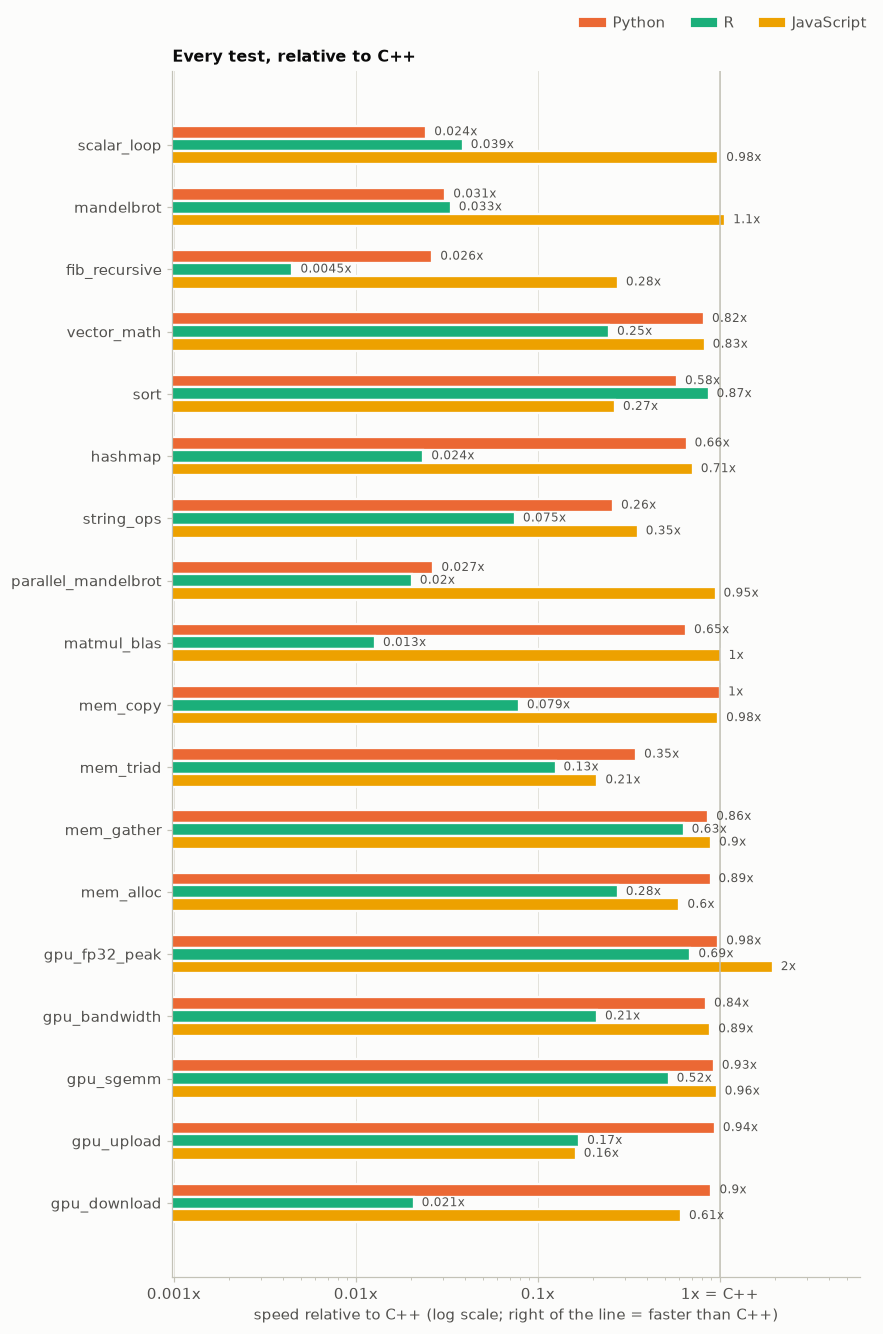

In [6]:
# Every test: speed relative to C++ (same data as above, before averaging)
fig, ax = plt.subplots(figsize=(8, 0.4 * len(ratio) * max(len(others), 2) / 2 + 1.3))
hbar_groups(ax, list(ratio.index), others, lambda g, l: ratio.loc[g, l],
            label_of=lambda g, l, v: f"{v:.2g}x", log=True)
ax.set_xlim(right=max(2, np.nanmax(ratio[others].values) * 3) if others else 2)
ax.axvline(1, color=AXIS, lw=1)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"1x = {REF}" if v == 1 else f"{v:g}x"))
ax.set_xlabel(f"speed relative to {REF} (log scale; right of the line = faster than {REF})")
ax.set_title(f"Every test, relative to {REF}")
finish_layout(fig, others); plt.show()

## 4. CPU: one core, different execution paths

Each panel has its own unit. Loop tests execute explicit language-level code; vectorized and built-in tests
use each implementation's array operations or libraries. C++ and JavaScript use loops over arrays for
`vector_math`, while NumPy and R evaluate array expressions with different temporary allocations.

Read each operation separately. A fast built-in sort does not imply fast scalar loops, and the gap between
these groups is not a controlled estimate of the benefit of vectorizing one program. Recursive Fibonacci
also reports effective calls: compiler transformations can change the actual instructions executed.

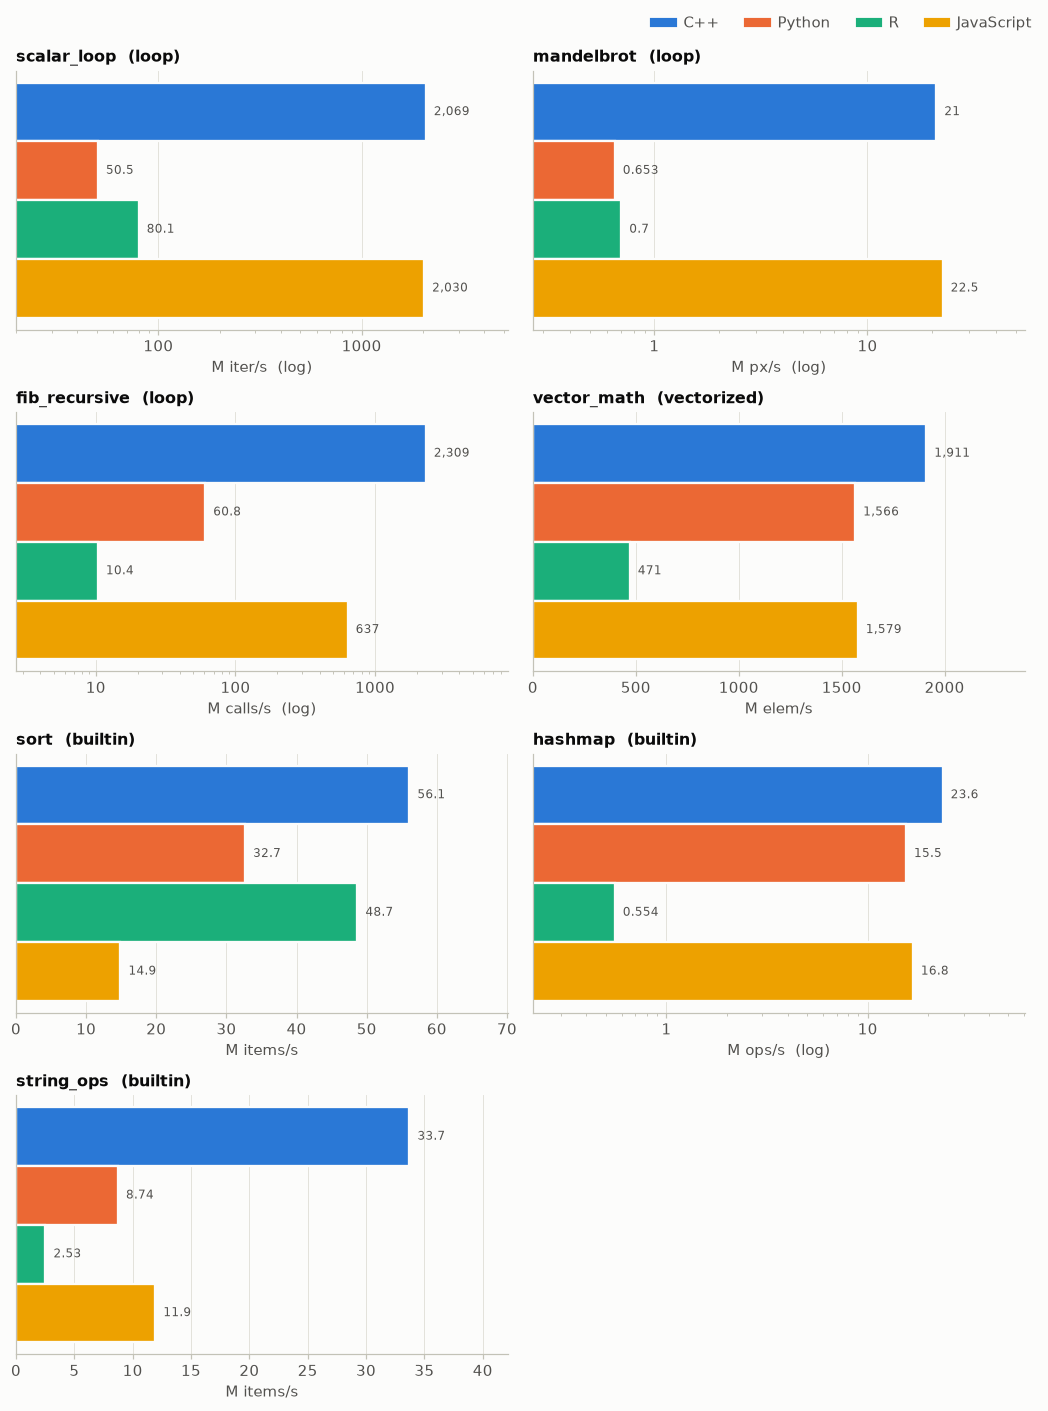

,unit,C++,Python,R,JavaScript,Python xC++,R xC++,JavaScript xC++
test,,,,,,,,
scalar_loop,M iter/s,"2,069",50.5,80.1,"2,030",0.0244,0.0387,0.981
mandelbrot,M px/s,21,0.653,0.7,22.5,0.031,0.0333,1.07
fib_recursive,M calls/s,"2,309",60.8,10.4,637,0.0263,0.00449,0.276
vector_math,M elem/s,"1,911","1,566",471,"1,579",0.819,0.246,0.826
sort,M items/s,56.1,32.7,48.7,14.9,0.582,0.868,0.266
hashmap,M ops/s,23.6,15.5,0.554,16.8,0.657,0.0235,0.711
string_ops,M items/s,33.7,8.74,2.53,11.9,0.259,0.0749,0.354


In [7]:
def test_panels(tests, ncols=2, log_if_spread=30):
    tests = [t for t in tests if t in rate_by.index]
    if not tests:
        print("No results for these tests.")
        return
    nrows = math.ceil(len(tests) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(9.5, 1.15 * nrows * max(len(langs), 2) / 2 + 0.9 * nrows),
                             squeeze=False)
    for ax, t in zip(axes.flat, tests):
        unit = tests_spec.set_index("test").unit[t]
        scale, label = DISPLAY[unit]
        vals = {l: rate_by.loc[t, l] / scale for l in langs if np.isfinite(rate_by.loc[t, l])}
        spread = max(vals.values()) / min(vals.values()) if vals else 1
        hbar_groups(ax, [t], langs, lambda g, l: vals.get(l, np.nan), log=spread > log_if_spread)
        style = tests_spec.set_index("test")["style"][t]
        ax.set_title(f"{t}  ({style})")
        ax.set_yticks([])
        ax.set_xlabel(label + ("  (log)" if spread > log_if_spread else ""))
    for ax in axes.flat[len(tests):]:
        ax.set_visible(False)
    finish_layout(fig, langs); plt.show()

def rate_table(tests):
    rows_ = []
    for t in [t for t in tests if t in rate_by.index]:
        scale, label = DISPLAY[tests_spec.set_index("test").unit[t]]
        rows_.append({"test": t, "unit": label, **{l: fmt(rate_by.loc[t, l] / scale) for l in langs},
                      **{f"{l} x{REF}": f"{ratio.loc[t, l]:.3g}" for l in langs if l != REF}})
    display(pd.DataFrame(rows_).set_index("test"))

single = [t for t in TEST_ORDER if test_cat[t] == "cpu_single"]
test_panels(single)
rate_table(single)

## 5. CPU: worker scaling and BLAS

**Parallel Mandelbrot** divides each language's workload among workers. Speedup is throughput with *n* workers
relative to that language's one-worker result; the companion throughput chart shows whether a well-scaling
implementation is fast in absolute terms. Full-mode sizes differ by language, so scheduling overhead can
represent different shares of the timed work.

The gray line represents ideal scaling with identical workers and no overhead. Hybrid core types, SMT,
scheduling, shared resources and clock changes can all limit scaling. The test does not pin each worker to
a particular core type. Python and JavaScript pools are started before timing; R's fork-based path on
Linux/macOS includes startup, while its Windows socket cluster is prepared before timing.

**FP64 matrix multiplication** calls the installed BLAS. Its thread count and library are part of the result;
the category name “all cores” does not mean every BLAS implementation actually uses all cores.

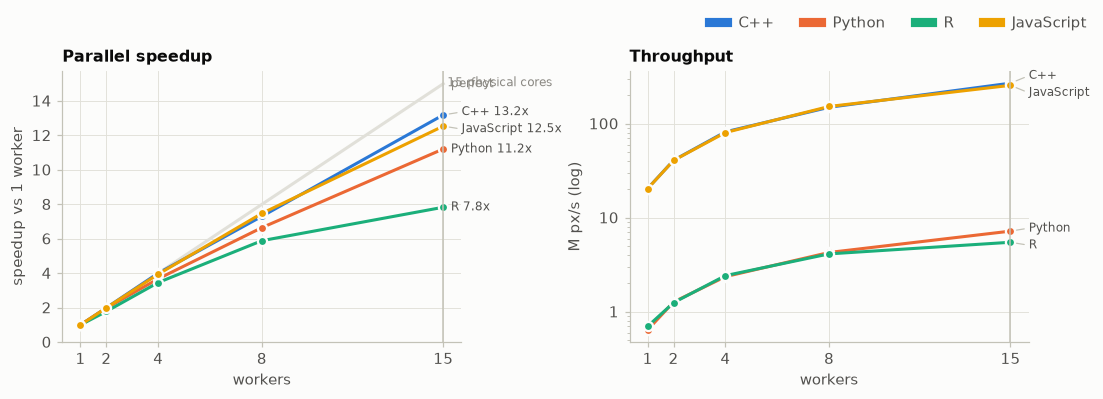

language,C++ speedup,Python speedup,R speedup,JavaScript speedup
threads,,,,
1,1.00,1.00,1.00,1.00
2,1.99,1.98,1.78,1.99
4,4.01,3.68,3.46,3.95
8,7.30,6.65,5.89,7.48
15,13.19,11.21,7.83,12.54


In [8]:
pm = med[med.test == "parallel_mandelbrot"].copy()
if pm.empty:
    print("No parallel_mandelbrot results.")
else:
    pm["speedup"] = pm.rate / pm.groupby("language").rate.transform(lambda r: r[pm.loc[r.index, "threads"] == 1].max())
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    ax = axes[0]
    xs = sorted(pm.threads.unique())
    ax.plot(xs, xs, color=GRID, lw=2, zorder=1)
    end_label(ax, xs[-1], xs[-1], "perfect", color=MUTED)
    for l in langs:
        d = pm[pm.language == l].sort_values("threads")
        ax.plot(d.threads, d.speedup, marker="o", color=COLORS[l], label=l, markeredgecolor=SURFACE, markeredgewidth=1.5)
        end_label(ax, d.threads.iloc[-1], d.speedup.iloc[-1], f"{l} {d.speedup.iloc[-1]:.1f}x")
    ax.axvline(PHYS, color=AXIS, lw=1)
    ax.text(PHYS, 0.98, f" {PHYS} physical cores", transform=ax.get_xaxis_transform(), color=MUTED, fontsize=8, va="top")
    ax.set_xticks(xs); ax.set_xlabel("workers"); ax.set_ylabel("speedup vs 1 worker")
    ax.set_title("Parallel speedup")
    ax.set_ylim(0, max(xs) * 1.05)

    ax = axes[1]
    for l in langs:
        d = pm[pm.language == l].sort_values("threads")
        ax.plot(d.threads, d.rate / 1e6, marker="o", color=COLORS[l], label=l, markeredgecolor=SURFACE, markeredgewidth=1.5)
        end_label(ax, d.threads.iloc[-1], d.rate.iloc[-1] / 1e6, l)
    ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xlabel("workers"); ax.set_ylabel("M px/s (log)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.axvline(PHYS, color=AXIS, lw=1)
    ax.set_title("Throughput")
    finish_layout(fig, langs); plt.show()
    display(pm.pivot(index="threads", columns="language", values="speedup")[langs].round(2)
              .rename(columns=lambda c: f"{c} speedup"))

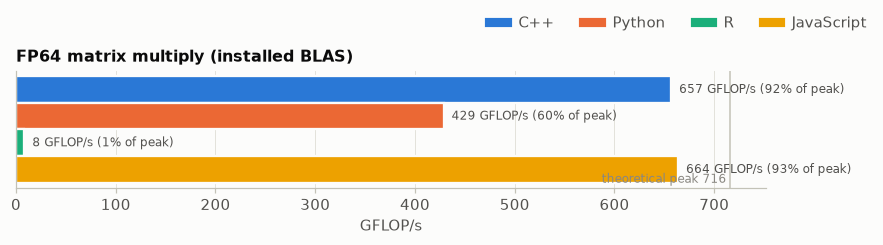

,size,threads,GFLOPs,BLAS
language,,,,
C++,4096.0,15,656.8,OpenBLAS
Python,4096.0,15,428.7,Apple's Accelerate
R,4096.0,1,8.4,R's own single-threaded reference BLAS
JavaScript,4096.0,15,663.8,OpenBLAS


In [9]:
# Matrix multiply through BLAS (all cores) against the CPU's theoretical FP64 peak
mm = best[best.test == "matmul_blas"].set_index("language").reindex(langs)
fig, ax = plt.subplots(figsize=(8, 2.2))
hbar_groups(ax, ["matmul_blas"], langs, lambda g, l: mm.rate.get(l, np.nan) / 1e9,
            label_of=lambda g, l, v: f"{v:.0f} GFLOP/s" + (f" ({100 * v / PEAK['cpu_fp64_gflops']:.0f}% of peak)"
                                                           if np.isfinite(PEAK["cpu_fp64_gflops"]) else ""))
ax.set_yticks([]); ax.set_xlabel("GFLOP/s"); ax.set_title("FP64 matrix multiply (installed BLAS)")
if np.isfinite(PEAK["cpu_fp64_gflops"]):
    peak_line(ax, PEAK["cpu_fp64_gflops"], f"theoretical peak {PEAK['cpu_fp64_gflops']:.0f}")
    ax.set_xlim(0, max(PEAK["cpu_fp64_gflops"], np.nanmax(mm.rate.values / 1e9)) * 1.05)   # matrix units can beat it
finish_layout(fig, langs); plt.show()
display(mm[["size", "threads", "rate"]].assign(
    GFLOPs=lambda d: (d.rate / 1e9).round(1),
    BLAS=[blas_kind(run_meta.get(l)) or run_meta.get(l, {}).get("blas", "unknown") for l in langs]
).drop(columns="rate"))

## 6. RAM: useful throughput, allocation and indexed reads

**Copy and STREAM triad** report useful bytes per second according to the specification. C++ can measure
multithreaded triad; the other implementations use one thread. NumPy and R's triad expressions also allocate
temporaries, whose additional memory traffic is not added to the reported work count. Compare thread counts
and operations before interpreting a difference as a memory-bandwidth limit.

**Allocation** includes allocating, filling, summing and releasing an array, not just reserving its address space.
The runner skips sizes above 40% of available RAM, so machines and languages may cover different sizes.
NumPy's [documented Linux huge-page advice](https://numpy.org/doc/stable/reference/global_state.html#madvise-hugepage-on-linux)
is a plausible contributor to the Dell allocation result. The stored observations do not isolate that mechanism;
a matched rerun with advice disabled would be needed to estimate its effect.

**Indexed reads** are summarized as elapsed nanoseconds per access. That quantity includes indexing, reading,
reduction and any temporaries, and can benefit from overlapping memory requests. It is not a direct DRAM-latency measurement.

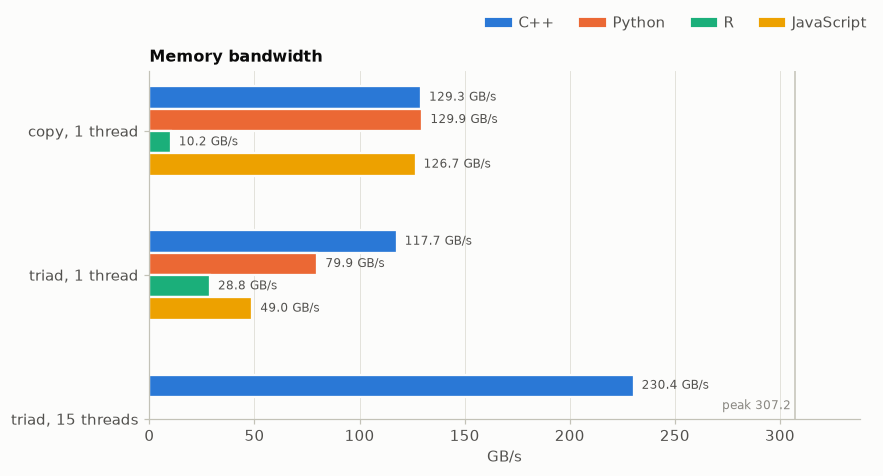

In [10]:
bw_groups = []
for t in ["mem_copy", "mem_triad"]:
    for th in sorted(med[(med.test == t)].threads.unique()):
        bw_groups.append((t, th))
bw = {(t, th, l): med[(med.test == t) & (med.threads == th) & (med.language == l)].rate.max() / 1e9
      for (t, th) in bw_groups for l in langs}
names = [f"{t.replace('mem_', '')}, {th} thread{'s' if th > 1 else ''}" for t, th in bw_groups]
if bw_groups:
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(bw_groups) * max(len(langs), 2) / 2 + 1.3))
    hbar_groups(ax, names, langs, lambda g, l: bw[bw_groups[names.index(g)] + (l,)],
                label_of=lambda g, l, v: f"{v:.1f} GB/s")
    peak_line(ax, PEAK["ram_gbs"], f"peak {PEAK['ram_gbs']:.1f}")
    ax.set_xlim(0, PEAK["ram_gbs"] * 1.1)
    ax.set_xlabel("GB/s"); ax.set_title("Memory bandwidth")
    finish_layout(fig, langs); plt.show()

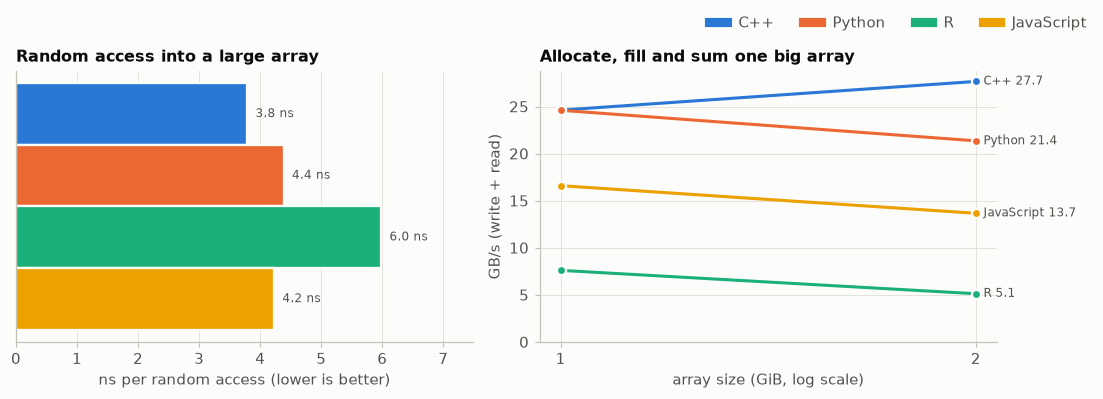

language,C++ seconds,Python seconds,R seconds,JavaScript seconds
GiB,,,,
1.0,0.09,0.09,0.28,0.13
2.0,0.16,0.20,0.84,0.31


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
g = best[best.test == "mem_gather"].set_index("language").reindex(langs)
ax = axes[0]
hbar_groups(ax, ["mem_gather"], langs, lambda _, l: 1e9 / g.rate.get(l, np.nan),
            label_of=lambda _, l, v: f"{v:.1f} ns")
ax.set_yticks([]); ax.set_xlabel("ns per random access (lower is better)")
ax.set_title("Random access into a large array")

ax = axes[1]
al = med[med.test == "mem_alloc"]
for l in langs:
    d = al[al.language == l].sort_values("size")
    if len(d):
        ax.plot(d["size"], d.rate / 1e9, marker="o", color=COLORS[l], label=l, markeredgecolor=SURFACE, markeredgewidth=1.5)
        end_label(ax, d["size"].iloc[-1], d.rate.iloc[-1] / 1e9, f"{l} {d.rate.iloc[-1] / 1e9:.1f}")
ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("array size (GiB, log scale)"); ax.set_ylabel("GB/s (write + read)")
ax.set_ylim(bottom=0)
ax.set_title("Allocate, fill and sum one big array")
finish_layout(fig, langs); plt.show()
display(al.pivot(index="size", columns="language", values="seconds").reindex(columns=langs).round(2)
          .rename(columns=lambda c: f"{c} seconds").rename_axis("GiB"))

## 7. GPU: separate resident-buffer work from transfers

C++, Python and R launch the [OpenCL kernels](common/kernels.cl); JavaScript launches their
[WebGPU translation](common/kernels.wgsl) through Dawn. The recorded backend is Vulkan on Linux,
Direct3D 12 on Windows and Metal on macOS. Source-level equivalence does not guarantee identical compiled arithmetic.

Kernel timings include launch and waiting for completion but exclude initial input upload. R additionally
allocates an output buffer and uses a blocking read to wait. Transfers are separate tests, including the
conversion between R's double-precision vectors and float32 GPU buffers. The combined GPU score therefore
mixes three resident-buffer tests with two transfers; it is not an upload–compute–download runtime.

**Known comparability caveat:** the Mac's JavaScript `gpu_fp32_peak` exceeds the estimated hardware peak.
The suite documents relaxed Metal math as the explanation: reassociation can reduce executed arithmetic
while the nominal FLOP count remains unchanged. Retain that observation, but do not treat it as evidence of
extra hardware capacity. The table below removes the flagged test from every language for a sensitivity analysis.
Passing a numerical tolerance check does not establish equal executed work.

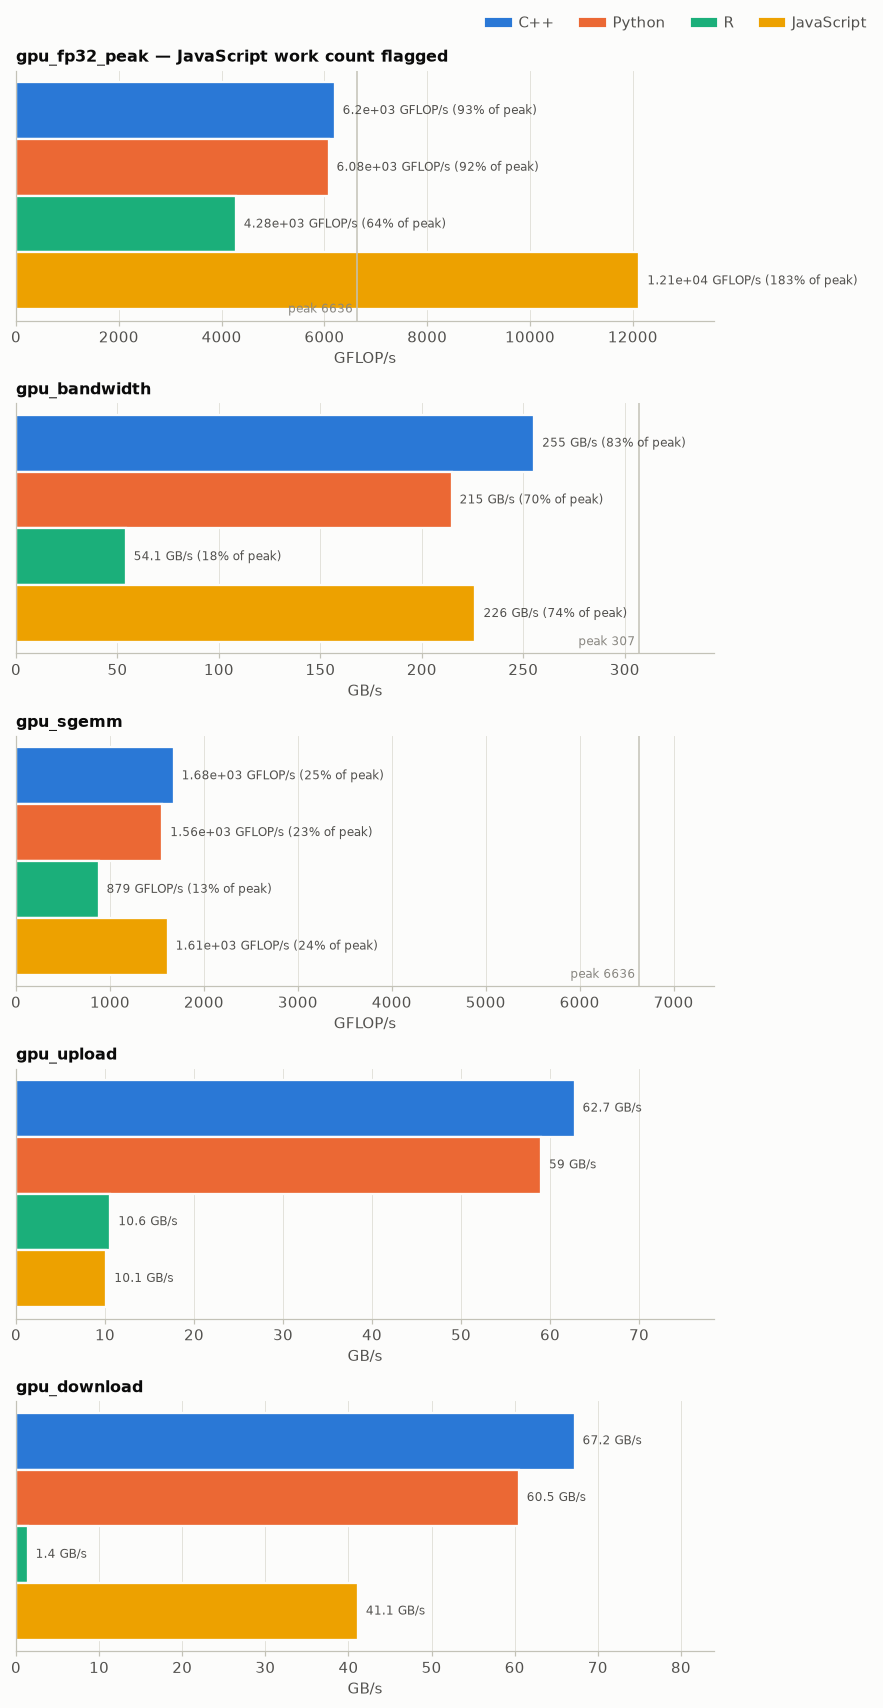

,unit,C++,Python,R,JavaScript,Python xC++,R xC++,JavaScript xC++
test,,,,,,,,
gpu_fp32_peak,GFLOP/s,"6,199","6,081","4,277","12,127",0.981,0.69,1.96
gpu_bandwidth,GB/s,255,215,54.1,226,0.841,0.212,0.887
gpu_sgemm,GFLOP/s,"1,678","1,557",879,"1,614",0.928,0.524,0.962
gpu_upload,GB/s,62.7,59,10.6,10.1,0.94,0.169,0.162
gpu_download,GB/s,67.2,60.5,1.4,41.1,0.9,0.0208,0.612


**Sensitivity analysis:** exclude `gpu_fp32_peak` from every language on this machine. The resident-buffer summary uses the remaining tests; the original charts retain the measured result.

,C++,Python,R,JavaScript
"scope, relative to C++",,,,
GPU: all recorded tests,1×,0.917×,0.193×,0.698×
Resident-buffer tests (2),1×,0.883×,0.333×,0.924×
Upload / download (2),1×,0.92×,0.0593×,0.315×
GPU: flagged test excluded,1×,0.901×,0.141×,0.539×
Overall: all recorded tests,1×,0.337×,0.0778×,0.684×
Overall: flagged test excluded,1×,0.336×,0.0719×,0.641×


In [12]:
gpu_tests = [t for t in TEST_ORDER if test_cat[t] == "gpu" and t in rate_by.index]
if not gpu_tests:
    print("No GPU results. Check `skipped` in the table of section 2 (OpenCL driver installed? RUSTICL_ENABLE=radeonsi?).")
else:
    gpu_langs = [l for l in langs if rate_by.loc[gpu_tests, l].notna().any()]
    missing = [l for l in langs if l not in gpu_langs]
    if missing:
        print("No GPU results for:", ", ".join(missing))
    fig, axes = plt.subplots(len(gpu_tests), 1, figsize=(8, 1.25 * len(gpu_tests) * max(len(gpu_langs), 2) / 2 + 0.6 * len(gpu_tests)),
                             squeeze=False)
    for ax, t in zip(axes.flat, gpu_tests):
        unit = tests_spec.set_index("test").unit[t]
        scale, label = DISPLAY[unit]
        peak = PEAK["gpu_fp32_gflops"] if unit == "FLOP" else (PEAK["gpu_mem_gbs"] if t == "gpu_bandwidth" else None)
        hbar_groups(ax, [t], gpu_langs, lambda _, l: rate_by.loc[t, l] / scale,
                    label_of=lambda _, l, v: f"{v:.3g} {label}" + (f" ({100 * v / peak:.0f}% of peak)" if peak and np.isfinite(peak) else ""))
        if peak is not None and np.isfinite(peak):
            peak_line(ax, peak, f"peak {peak:.0f}")
            ax.set_xlim(0, max(peak, float(rate_by.loc[t, gpu_langs].max()) / scale) * 1.12)
        ax.set_yticks([])
        ax.set_title(t + (" — JavaScript work count flagged" if flagged_gpu and t == "gpu_fp32_peak" else ""))
        ax.set_xlabel(label)
    finish_layout(fig, gpu_langs); plt.show()
    rate_table(gpu_tests)

profile_rows = {
    "GPU: all recorded tests": cat_score.loc["gpu"].to_dict() if "gpu" in cat_score.index else {},
    f"Resident-buffer tests ({len(scope['resident_tests'])})": scope["resident"],
    f"Upload / download ({len(scope['transfer_tests'])})": scope["transfer"],
}
if scope["excluded"]:
    profile_rows.update({"GPU: flagged test excluded": scope["gpu"],
                         "Overall: all recorded tests": overall.to_dict(),
                         "Overall: flagged test excluded": scope["overall"]})
    display(Markdown("**Sensitivity analysis:** exclude `gpu_fp32_peak` from every language on this machine. "
                     "The resident-buffer summary uses the remaining tests; the original charts retain the measured result."))
display(pd.DataFrame(profile_rows).T.reindex(columns=langs).map(
    lambda v: f"{v:.3g}×" if pd.notna(v) else "—").rename_axis(f"scope, relative to {REF}"))

## 8. Throughput relative to estimated hardware peaks

These percentages divide the best selected rate by the corresponding model in section 2. The RAM summary
may use a multithreaded C++ triad. The CPU model assumes per-core FP64 arithmetic widths and high clocks;
it does not model every library's instruction path or all sustained power limits.

A value above 100% can indicate an incomplete peak model, cache effects or a mismatch between nominal and
executed work. The flagged JavaScript GPU compute result is one such case, not a utilization achievement.
CPU BLAS uses FP64 and the GPU matrix kernel uses FP32 with a different implementation, so their rates do not
establish the speedup from moving the same application to a GPU.

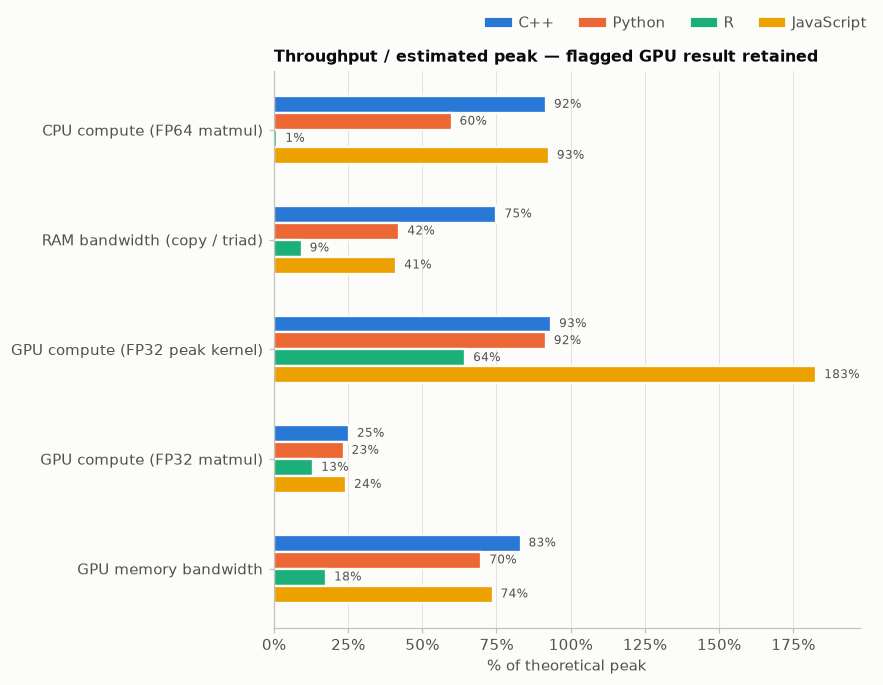

,C++ %,Python %,R %,JavaScript %
CPU compute (FP64 matmul),91.7,59.9,1.2,92.7
RAM bandwidth (copy / triad),75.0,42.3,9.4,41.2
GPU compute (FP32 peak kernel),93.4,91.6,64.4,182.8
GPU compute (FP32 matmul),25.3,23.5,13.2,24.3
GPU memory bandwidth,83.1,69.9,17.6,73.7


In [13]:
def best_rate(tests, l):
    vals = [rate_by.loc[t, l] for t in tests if t in rate_by.index and np.isfinite(rate_by.loc[t, l])]
    return max(vals) if vals else np.nan

UTIL = [("CPU compute (FP64 matmul)", ["matmul_blas"], 1e9, PEAK["cpu_fp64_gflops"]),
        ("RAM bandwidth (copy / triad)", ["mem_copy", "mem_triad"], 1e9, PEAK["ram_gbs"]),
        ("GPU compute (FP32 peak kernel)", ["gpu_fp32_peak"], 1e9, PEAK["gpu_fp32_gflops"]),
        ("GPU compute (FP32 matmul)", ["gpu_sgemm"], 1e9, PEAK["gpu_fp32_gflops"]),
        ("GPU memory bandwidth", ["gpu_bandwidth"], 1e9, PEAK["gpu_mem_gbs"])]
util = pd.DataFrame({l: {name: 100 * best_rate(ts, l) / s / p for name, ts, s, p in UTIL} for l in langs})
util = util.dropna(how="all")
fig, ax = plt.subplots(figsize=(8, 0.5 * len(util) * max(len(langs), 2) / 2 + 1.2))
hbar_groups(ax, list(util.index), langs, lambda g, l: util.loc[g, l], label_of=lambda g, l, v: f"{v:.0f}%")
ax.set_xlim(0, max(100, np.nanmax(util.values) * 1.08)); ax.set_xlabel("% of theoretical peak")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Throughput / estimated peak" + (" — flagged GPU result retained" if flagged_gpu else ""))
finish_layout(fig, langs); plt.show()
display(util.round(1).rename(columns=lambda c: f"{c} %"))

## 9. Variation within the selected runs

Coefficient of variation (standard deviation divided by mean) of repeated **rates**, using population standard
deviation. Where a test has several sizes or worker counts, this chart shows the largest configuration CV.
Single-observation configurations, including allocation and parallel Mandelbrot, have no within-run CV.

This describes repeatability within the selected run, not uncertainty across machines or independent sessions.
A large CV can reflect short timings, background work, clock changes or other effects; it does not diagnose
thermal throttling. Between-run ranges on the results page describe a separate source of variation.

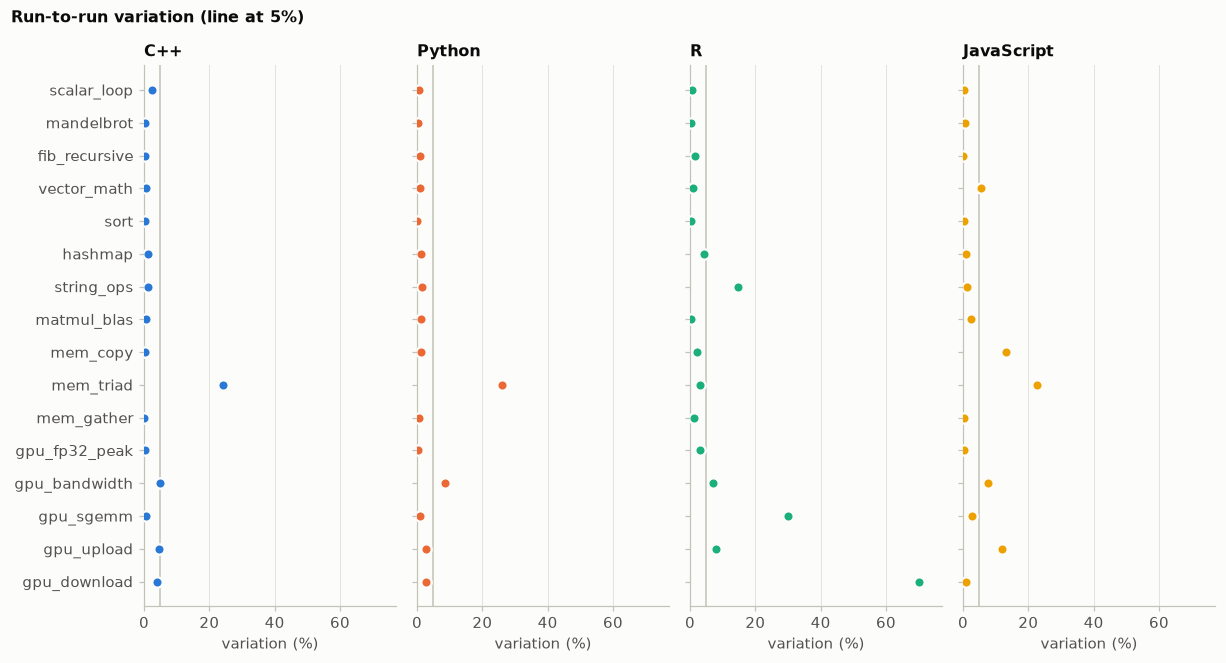

In [14]:
cv = med[med.cv.notna()].groupby(["test", "language"]).cv.max().unstack().reindex(columns=langs)
cv = cv.reindex([t for t in TEST_ORDER if t in cv.index])
if cv.empty:
    print("Only one repetition per test (e.g. verify mode) - nothing to show.")
else:
    xmax = max(10, np.nanmax(100 * cv.values) * 1.1)
    fig, axes = plt.subplots(1, len(langs), figsize=(2.4 * len(langs) + 1.6, 0.3 * len(cv) + 1.3),
                             sharey=True, squeeze=False)
    for ax, l in zip(axes.flat, langs):          # one panel per language (small multiples)
        ax.scatter(100 * cv[l], range(len(cv)), s=46, color=COLORS[l], edgecolors=SURFACE, linewidths=1.5, zorder=3)
        ax.axvline(5, color=AXIS, lw=1)
        ax.set_xlim(0, xmax); ax.set_title(l); ax.grid(axis="y", visible=False)
        ax.set_xlabel("variation (%)")
    axes[0, 0].set_yticks(range(len(cv)), cv.index); axes[0, 0].invert_yaxis()
    fig.suptitle("Run-to-run variation (line at 5%)", x=0.01, ha="left", fontweight="bold", fontsize=10.5, color=INK)
    plt.tight_layout(); plt.show()

## 10. Sensor context during the runs

The runner samples sensors once per second. Shaded spans identify the language being run; they do not identify
individual test boundaries. Rising temperature alongside falling clock speed is consistent with throttling,
but changing workload or power policy can also produce that pattern. These logs alone do not establish a cause.

macOS logs the hottest available SoC die sensor, GPU load and RAM use, but this runner does not collect its
privileged clock counters. Windows logs effective CPU clocks and available GPU data, but no CPU temperature.
Missing sensor values are not evidence that the machine stayed cool or held a constant clock.

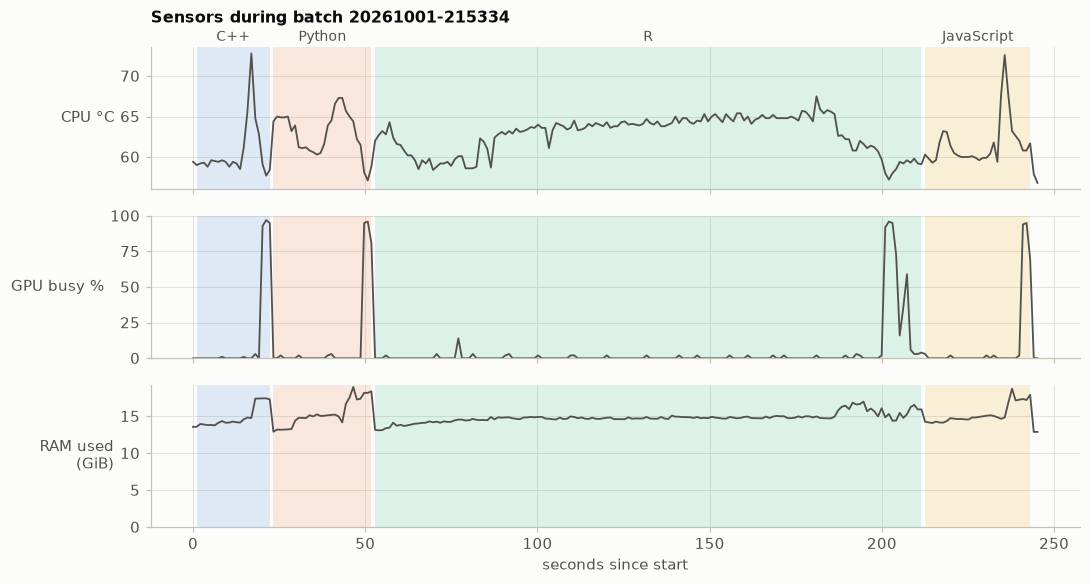

,seconds,max_cpu_temp_c,avg_cpu_mhz,max_gpu_busy_pct,max_ram_gib
phase,,,,,
C++,21.2,72.8,NaN,97,17.4
JavaScript,30.5,72.6,NaN,95,18.7
Python,28.4,67.3,NaN,96,19.0
R,158.6,67.5,NaN,96,17.0


In [15]:
folders = sorted(set(data.folder))
sensor_files = [Path(f) / f"sensors_{b}.csv" for f in folders for b in sorted(set(chosen.batch.dropna()))]
sensor_files = [p for p in sensor_files if p.exists()]
if not sensor_files:
    print("No sensor log for these runs (they were not started through run_all.sh).")
for path in sensor_files:
    s = pd.read_csv(path)
    if s.empty:
        continue
    s["t"] = s.time - s.time.iloc[0]
    panels = [("cpu_temp_c", "CPU °C", None), ("cpu_mhz_avg", "CPU MHz\n(avg of cores)", None),
              ("gpu_busy_pct", "GPU busy %", (0, 100)), ("mem_used_gib", "RAM used\n(GiB)", "zero")]
    panels = [(c, lab, lim) for c, lab, lim in panels if c in s and s[c].notna().any()]
    fig, axes = plt.subplots(len(panels), 1, figsize=(10, 1.6 * len(panels) + 0.6), sharex=True, squeeze=False)
    phase_runs = (s.phase != s.phase.shift()).cumsum()
    for ax, (col, lab, lim) in zip(axes.flat, panels):
        ax.plot(s.t, s[col], color=INK2, lw=1.2)
        if lim == "zero":
            ax.set_ylim(bottom=0)
        elif lim:
            ax.set_ylim(*lim)
        ax.set_ylabel(lab, rotation=0, ha="right", va="center")
        for _, seg in s.groupby(phase_runs):
            name = PHASE_NAMES.get(seg.phase.iloc[0])
            if name:
                ax.axvspan(seg.t.iloc[0], seg.t.iloc[-1], color=COLORS[name], alpha=0.14, lw=0)
    top = axes.flat[0]
    for _, seg in s.groupby(phase_runs):
        name = PHASE_NAMES.get(seg.phase.iloc[0])
        if name:
            top.text((seg.t.iloc[0] + seg.t.iloc[-1]) / 2, 1.02, name, transform=top.get_xaxis_transform(),
                     ha="center", va="bottom", color=INK2, fontsize=9)
    axes.flat[-1].set_xlabel("seconds since start")
    top.set_title(f"Sensors during batch {path.stem.replace('sensors_', '')}", pad=16)
    plt.tight_layout(); plt.show()
    summary = s[s.phase.isin(PHASE_NAMES)].groupby("phase").agg(
        seconds=("t", lambda t: t.max() - t.min()), max_cpu_temp_c=("cpu_temp_c", "max"),
        avg_cpu_mhz=("cpu_mhz_avg", "mean"), max_gpu_busy_pct=("gpu_busy_pct", "max"), max_ram_gib=("mem_used_gib", "max"))
    display(summary.rename(index=PHASE_NAMES).round(1))

## 11. Findings for the selected machine

The statements below are recomputed from the selected observations. They distinguish aggregate scores,
specific operations, library configuration and scaling. The flagged GPU compute result remains in the
original scores but is excluded when selecting a language's strongest individual result.

In [16]:
lines = []
others = [l for l in langs if l != REF]
for l in others:
    r = ratio[l].drop(index=scope["excluded"], errors="ignore").dropna()
    if len(r):
        slow, fast = r.idxmin(), r.idxmax()
        lines.append(f"- **{l}: {overall[l]:.2g}× {REF} Overall.** Its highest relative throughput is "
                     f"`{fast}` ({r[fast]:.2g}×); its lowest is `{slow}` ({r[slow]:.2g}×). "
                     f"The score includes {int(ratio[l].notna().sum())} of {len(TEST_ORDER)} specified tests.")
loop_tests = [t for t in ratio.index if tests_spec.set_index("test")["style"][t] == "loop"]
lib_tests = [t for t in ratio.index if tests_spec.set_index("test")["style"][t] in ("vectorized", "builtin", "blas")
             and test_cat[t] != "gpu"]
for l in others:
    a, b = gmean(ratio.loc[loop_tests, l]), gmean(ratio.loc[lib_tests, l])
    if np.isfinite(a) and np.isfinite(b):
        lines.append(f"- **{l}'s execution paths differ:** the loop group scores {a:.2g}× {REF}; "
                     f"the library/vectorized group scores {b:.2g}×. These groups contain different tasks, "
                     "so their ratio is not a measured gain from rewriting one program.")
if not pm.empty:
    sp = pm.loc[pm.groupby("language").speedup.idxmax()].set_index("language")
    lines.append("- **Best worker counts:** " + "; ".join(
        f"{l}: {sp.speedup[l]:.1f}× its one-worker throughput at {int(sp.threads[l])} workers "
        f"({sp.rate[l] / 1e6:.3g} M px/s)" for l in langs if l in sp.index) +
        ". Select worker counts from both scaling and absolute throughput; the maximum available is not always best.")
if not mm.dropna(subset=["rate"]).empty:
    lines.append("- **BLAS results depend on configuration:** " + "; ".join(
        f"{l}: {mm.rate[l] / 1e9:.3g} GFLOP/s using {blas_kind(run_meta.get(l)) or 'the recorded BLAS'}"
        for l in langs if pd.notna(mm.rate.get(l))) + ". Library, threading and hardware effects are combined here.")
for l in others:
    a, b = scope["resident"].get(l), scope["transfer"].get(l)
    if a is not None and b is not None:
        lines.append(f"- **{l} on the GPU:** resident-buffer tests average {a:.2g}× {REF}; "
                     f"upload/download average {b:.2g}×. The value of keeping data on the GPU depends on "
                     "the application's actual sequence of transfers and kernels.")
if flagged_gpu:
    lines.append(f"- **The flagged GPU test changes the summary:** excluding `gpu_fp32_peak` from every language "
                 f"changes JavaScript's GPU score from {cat_score.loc['gpu', 'JavaScript']:.2g}× to "
                 f"{scope['gpu']['JavaScript']:.2g}×, and Overall from {overall['JavaScript']:.2g}× to "
                 f"{scope['overall']['JavaScript']:.2g}×. No measured rate is changed.")
lines.append("- **Uncertainty:** the summaries select the fastest measured configuration and are descriptive. "
             "Within-run CV and between-run ranges do not provide confidence intervals for a universal language ranking.")
display(Markdown("\n\n".join(lines)))

- **Python: 0.34× C++ Overall.** Its highest relative throughput is `mem_copy` (1×); its lowest is `scalar_loop` (0.024×). The score includes 18 of 18 specified tests.

- **R: 0.078× C++ Overall.** Its highest relative throughput is `sort` (0.87×); its lowest is `fib_recursive` (0.0045×). The score includes 18 of 18 specified tests.

- **JavaScript: 0.68× C++ Overall.** Its highest relative throughput is `mandelbrot` (1.1×); its lowest is `gpu_upload` (0.16×). The score includes 18 of 18 specified tests.

- **Python's execution paths differ:** the loop group scores 0.027× C++; the library/vectorized group scores 0.62×. These groups contain different tasks, so their ratio is not a measured gain from rewriting one program.

- **R's execution paths differ:** the loop group scores 0.018× C++; the library/vectorized group scores 0.13×. These groups contain different tasks, so their ratio is not a measured gain from rewriting one program.

- **JavaScript's execution paths differ:** the loop group scores 0.66× C++; the library/vectorized group scores 0.57×. These groups contain different tasks, so their ratio is not a measured gain from rewriting one program.

- **Best worker counts:** C++: 13.2× its one-worker throughput at 15 workers (270 M px/s); Python: 11.2× its one-worker throughput at 15 workers (7.21 M px/s); R: 7.8× its one-worker throughput at 15 workers (5.49 M px/s); JavaScript: 12.5× its one-worker throughput at 15 workers (256 M px/s). Select worker counts from both scaling and absolute throughput; the maximum available is not always best.

- **BLAS results depend on configuration:** C++: 657 GFLOP/s using OpenBLAS; Python: 429 GFLOP/s using Apple's Accelerate; R: 8.37 GFLOP/s using R's own single-threaded reference BLAS; JavaScript: 664 GFLOP/s using OpenBLAS. Library, threading and hardware effects are combined here.

- **Python on the GPU:** resident-buffer tests average 0.88× C++; upload/download average 0.92×. The value of keeping data on the GPU depends on the application's actual sequence of transfers and kernels.

- **R on the GPU:** resident-buffer tests average 0.33× C++; upload/download average 0.059×. The value of keeping data on the GPU depends on the application's actual sequence of transfers and kernels.

- **JavaScript on the GPU:** resident-buffer tests average 0.92× C++; upload/download average 0.31×. The value of keeping data on the GPU depends on the application's actual sequence of transfers and kernels.

- **The flagged GPU test changes the summary:** excluding `gpu_fp32_peak` from every language changes JavaScript's GPU score from 0.7× to 0.54×, and Overall from 0.68× to 0.64×. No measured rate is changed.

- **Uncertainty:** the summaries select the fastest measured configuration and are descriptive. Within-run CV and between-run ranges do not provide confidence intervals for a universal language ranking.

## 12. Compare recorded machine configurations

Select the newest run of each language on every machine in the chosen mode. Ratios use the selected detailed
machine as their reference: 2× means twice its throughput for the same language. The GitHub Pages comparison
instead uses the machine with the oldest full run, so its reference can differ from this notebook's.

Matching `suite_tests_sha` values establish matching test definitions and GPU sources in the recorded snapshots.
They do not equalize compiler versions, BLAS, GPU APIs, power policies or input sizes across languages.
Hardware and OS change together in this dataset; these comparisons cannot isolate either effect.
Missing results are omitted from geometric means and can change coverage. Use the category and per-test
results to determine whether an aggregate reflects the workload of interest.

,apple-inc-macbook-pro-14-inch-m5-pro,alienware-m16-r1,dell-inc-inspiron-14-7425-2-in-1
product,"MacBook Pro (14-inch, M5 Pro)",Alienware m16 R1,Inspiron 14 7425 2-in-1
cpu,Apple M5 Pro,13th Gen Intel(R) Core(TM) i9-13900HX,AMD Ryzen 5 5625U with Radeon Graphics
physical_cores,15,24,6
cpu_max_mhz,4608,5283,4390
ram_gib,24.0,63.7,61.2
ram_type,LPDDR5X,DDR5,DDR4
ram_speed_mts,9600,5200,3200
gpus,Apple M5 Pro,NVIDIA GeForce RTX 4090 Laptop GPU;Intel(R) UH...,"Advanced Micro Devices, Inc. [AMD/ATI] Barcelo..."
os,macOS 26.5.2,Windows 11 Home 25H2,Ubuntu 26.04.1 LTS
suite_tests_sha,96c2e949ae9d,96c2e949ae9d,96c2e949ae9d


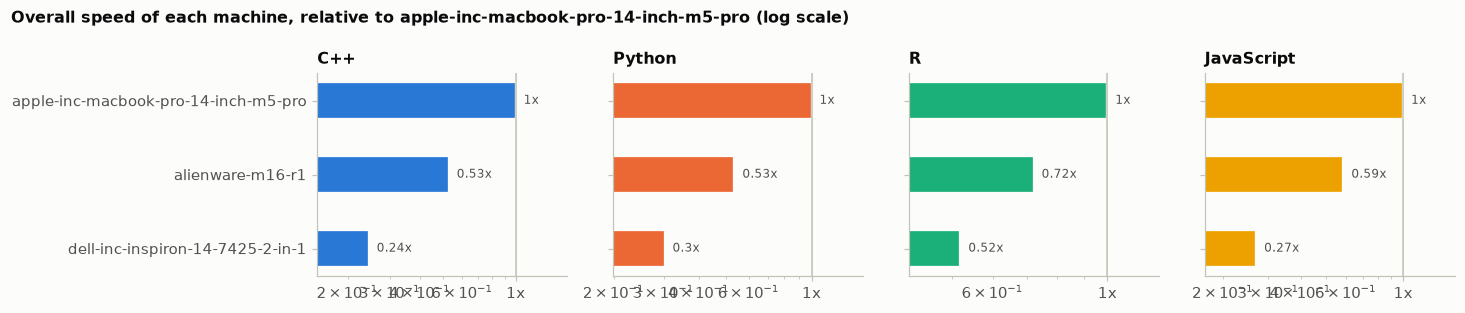

machine,apple-inc-macbook-pro-14-inch-m5-pro,alienware-m16-r1,dell-inc-inspiron-14-7425-2-in-1
overall vs apple-inc-macbook-pro-14-inch-m5-pro,,,
C++,1x,0.527x,0.245x
JavaScript,1x,0.586x,0.269x
Python,1x,0.534x,0.302x
R,1x,0.72x,0.52x


machine                     apple-inc-macbook-pro-14-inch-m5-pro  \
language   category                                                
C++        CPU, all cores                                     1x   
           CPU, single core                                   1x   
           GPU                                                1x   
           RAM                                                1x   
JavaScript CPU, all cores                                     1x   
           CPU, single core                                   1x   
           GPU                                                1x   
           RAM                                                1x   
Python     CPU, all cores                                     1x   
           CPU, single core                                   1x   
           GPU                                                1x   
           RAM                                                1x   
R          CPU, all cores                                     1x   
           CPU, single core                                   1x   
           GPU                                                1x   
           RAM                                                1x   

machine                     alienware-m16-r1 dell-inc-inspiron-14-7425-2-in-1  
language   category                                                            
C++        CPU, all cores             0.647x                           0.423x  
           CPU, single core           0.443x                           0.372x  
           GPU                         1.08x                           0.116x  
           RAM                        0.249x                           0.197x  
JavaScript CPU, all cores             0.641x                           0.401x  
           CPU, single core           0.473x                           0.397x  
           GPU                        0.933x                           0.111x  
           RAM                        0.418x                           0.297x  
Python     CPU, all cores             0.538x                            0.37x  
           CPU, single core           0.565x                           0.574x  
           GPU                         1.19x                           0.122x  
           RAM                        0.225x                           0.321x  
R          CPU, all cores             0.662x                            2.42x  
           CPU, single core           0.583x                           0.399x  
           GPU                         1.22x                            0.23x  
           RAM                        0.573x                           0.328x

,apple-inc-macbook-pro-14-inch-m5-pro,alienware-m16-r1,dell-inc-inspiron-14-7425-2-in-1
overall vs C++ on the same machine,,,
C++,1x,1x,1x
Python,0.337x,0.342x,0.416x
R,0.0778x,0.106x,0.165x
JavaScript,0.684x,0.761x,0.751x


In [17]:
cmp_runs = runs[runs["mode"] == mode].sort_values("started").groupby(["machine", "language"]).tail(1)
machines = sorted(set(cmp_runs.machine), key=lambda m: (m != machine, m))   # analysed machine first
if len(machines) < 2:
    print(f"Only one machine ({machine}) has '{mode}' results so far. Run ./run_all.sh on another computer, "
          "then add its results/<machine>/ folder here (for example through the git repository).")
else:
    hw_keys = ["product", "cpu", "physical_cores", "cpu_max_mhz", "ram_gib", "ram_type", "ram_speed_mts", "gpus", "os", "suite_tests_sha"]
    display(pd.DataFrame({m: {k: system_of(m).get(k, "") or "-" for k in hw_keys} for m in machines}))
    shas = [system_of(m, set(cmp_runs[cmp_runs.machine == m].batch)).get("suite_tests_sha") for m in machines]
    if not all(shas) or len(set(shas)) > 1:
        print("Warning: test/kernel hashes are missing or differ; "
              "their rates may not be comparable.")

    cmp = rows[rows.run_key.isin(cmp_runs.run_key)]
    cmed = cmp.groupby(["machine", "language", "test", "threads", "size"], as_index=False).rate.median()
    cbest = cmed.groupby(["machine", "language", "test"]).rate.max().unstack("machine")[machines]
    rel = cbest.div(cbest[machine], axis=0).reset_index()           # speed vs the analysed machine
    rel["category"] = rel.test.map(test_cat)
    by_cat = rel.groupby(["language", "category"])[machines].agg(gmean)
    overall_m = by_cat.groupby(level="language").agg(gmean)
    cl = [l for l in LANGS if l in overall_m.index]

    fig, axes = plt.subplots(1, len(cl), figsize=(2.9 * len(cl) + 1.8, 0.45 * len(machines) + 1.5),
                             sharey=True, squeeze=False)
    y = np.arange(len(machines))
    for ax, l in zip(axes.flat, cl):                # one panel per language (colour = language)
        vals = overall_m.loc[l, machines].astype(float)
        ax.barh(y, vals, height=0.5, color=COLORS[l], edgecolor=SURFACE, linewidth=1.5)
        for yi, v in zip(y, vals):
            if np.isfinite(v):
                ax.text(v, yi, f"  {v:.2g}x", va="center", fontsize=8, color=INK2)
        ax.set_xscale("log"); ax.axvline(1, color=AXIS, lw=1); ax.margins(x=0.35)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}x"))
        ax.set_title(l); ax.grid(axis="y", visible=False)
    axes[0, 0].set_yticks(y, machines); axes[0, 0].invert_yaxis()
    fig.suptitle(f"Overall speed of each machine, relative to {machine} (log scale)",
                 x=0.01, ha="left", fontweight="bold", fontsize=10.5, color=INK)
    plt.tight_layout(); plt.show()

    display(overall_m[machines].map(lambda v: f"{v:.3g}x" if np.isfinite(v) else "-")
              .rename_axis(f"overall vs {machine}"))
    display(by_cat[machines].map(lambda v: f"{v:.3g}x" if np.isfinite(v) else "-")
              .rename(index=CAT_TITLES, level="category"))

    # How far each language is from C++ on each machine (does the gap change with the hardware?)
    gap = {}
    for m in machines:
        b = cbest[m].unstack("language")
        if "C++" not in b:
            continue
        r = b.div(b["C++"], axis=0)
        cat = pd.DataFrame({c: r[r.index.map(test_cat) == c].apply(gmean) for c in CATEGORIES}).T.dropna(how="all")
        gap[m] = cat.apply(gmean)
    if gap:
        display(pd.DataFrame(gap)[list(gap)].reindex(LANGS).dropna(how="all")
                  .map(lambda v: f"{v:.3g}x" if np.isfinite(v) else "-").rename_axis("overall vs C++ on the same machine"))

## 13. Conclusions and next experiments

The strongest conclusion is that **execution path and workload determine how much the language matters**.
Read explicit loops, optimized library calls, worker scaling, memory operations and GPU transfers separately.
A good Overall score describes this suite's weighting; it does not establish the best language or machine for every task.

The synthesis below identifies leaders only within the recorded dataset. The next useful experiments would be:

- **Loop-heavy work:** compare alternative implementations of the same task at matched input sizes before estimating a rewrite's benefit.
- **Matrix-heavy work:** rerun with matched BLAS libraries and thread settings to separate installation effects from hardware effects.
- **Memory-heavy work:** compare the same array sizes and worker counts; vary huge-page advice separately if investigating allocation.
- **GPU-heavy work:** time the application's complete transfer–kernel sequence and validate operation counts under the compiler settings in use.
- **Small differences:** collect additional independent runs, vary run order and hold power settings constant before claiming a stable advantage.

The current results provide a reproducible starting point for those tests. They do not measure battery life,
energy per operation, long-duration sustained performance or complete scientific application throughput.


In [18]:
conclusions = []
if len(machines) > 1 and "C++" in overall_m.index:
    ranked = overall_m.loc["C++"].dropna().sort_values(ascending=False)
    names = {m: system_of(m).get("product") or m for m in machines}
    conclusions.append("**Recorded C++ Overall ranking:** " + "; ".join(
        f"{names[m]} {v:.2g}×" for m, v in ranked.items()) + f", relative to {names[machine]}. "
        "This weights the four hardware categories equally.")
    for t, label in [("gpu_fp32_peak", "FP32 GPU compute"), ("gpu_sgemm", "FP32 GPU matrix multiply"),
                     ("gpu_upload", "GPU upload"), ("gpu_download", "GPU download")]:
        if ("C++", t) in cbest.index:
            r = cbest.loc[("C++", t)].dropna().sort_values(ascending=False)
            unit = "TFLOP/s" if t in ("gpu_fp32_peak", "gpu_sgemm") else "GB/s"
            scale = 1e12 if unit == "TFLOP/s" else 1e9
            if len(r):
                conclusions.append(f"**{label}, C++:** " + "; ".join(
                    f"{names[m]} {v / scale:.3g} {unit}" for m, v in r.items()) + ".")
    conclusions.append("The GPU ranking can differ between arithmetic and transfers. Match the hardware comparison "
                       "to the workload, then measure the complete application under its intended software configuration.")
else:
    conclusions.append("Only one machine is available in this mode; the selected-machine findings support "
                       "implementation comparisons, but no machine ranking.")
display(Markdown("\n\n".join(conclusions)))


**Recorded C++ Overall ranking:** MacBook Pro (14-inch, M5 Pro) 1×; Alienware m16 R1 0.53×; Inspiron 14 7425 2-in-1 0.24×, relative to MacBook Pro (14-inch, M5 Pro). This weights the four hardware categories equally.

**FP32 GPU compute, C++:** Alienware m16 R1 41.8 TFLOP/s; MacBook Pro (14-inch, M5 Pro) 6.2 TFLOP/s; Inspiron 14 7425 2-in-1 0.786 TFLOP/s.

**FP32 GPU matrix multiply, C++:** Alienware m16 R1 7.29 TFLOP/s; MacBook Pro (14-inch, M5 Pro) 1.68 TFLOP/s; Inspiron 14 7425 2-in-1 0.122 TFLOP/s.

**GPU upload, C++:** MacBook Pro (14-inch, M5 Pro) 62.7 GB/s; Inspiron 14 7425 2-in-1 14.2 GB/s; Alienware m16 R1 10.4 GB/s.

**GPU download, C++:** MacBook Pro (14-inch, M5 Pro) 67.2 GB/s; Alienware m16 R1 10.3 GB/s; Inspiron 14 7425 2-in-1 4.15 GB/s.

The GPU ranking can differ between arithmetic and transfers. Match the hardware comparison to the workload, then measure the complete application under its intended software configuration.